# Homework#4 EDA Assignment

**Dataset:** Austin Animal Center Found Pets Map

**Source:** https://data.austintexas.gov/Locations-and-Maps/Austin-Animal-Center-Found-Pets-Map/hye6-gvq2

**File used:** Austin_Animal_Center_Stray_Map_20260318.csv

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Read the dataset
df = pd.read_csv("Austin_Animal_Center_Stray_Map_20260318.csv")

# Quick cleanup so we can graph numeric columns
# Get date parts from Intake Date 
intake_dt = pd.to_datetime(df["Intake Date"].astype(str).str.strip(), format="%m/%d/%y", errors="coerce")
df["Intake Year"] = intake_dt.dt.year
df["Intake Month"] = intake_dt.dt.month
df["Intake Day"] = intake_dt.dt.day
df["Intake Weekday"] = intake_dt.dt.weekday

# Convert Age text to weeks
age_parts = df["Age"].astype(str).str.extract(r"(?i)(\d+)\s*(day|week|month|year)")
age_value = pd.to_numeric(age_parts[0], errors="coerce")
age_unit = age_parts[1].str.lower()
unit_to_weeks = {"day": 1/7, "week": 1, "month": 4.345, "year": 52.143}
df["Age Weeks"] = age_value * age_unit.map(unit_to_weeks)

# Turn At AAC into 1/0
df["At AAC Binary"] = df["At AAC"].astype(str).str.contains("Yes", case=False, na=False).astype(int)

# Numeric columns for this EDA
numeric_cols = ["Intake Year", "Intake Month", "Intake Day", "Intake Weekday", "Age Weeks", "At AAC Binary"]

df.head()

,Animal ID,Found Location,At AAC,Intake Date,Type,Looks Like,Color,Sex,Age,Image Link,Intake Year,Intake Month,Intake Day,Intake Weekday,Age Weeks,At AAC Binary
0,A929612,W N GUADALUPE ST AUSTIN 78751,Yes (come to the shelter),5/2/25,Cat,Domestic Shorthair,Black/White,Intact Male,3 months,http://www.petharbor.com/pet.asp?uaid=ASTN.A92...,2025,5,2,4,13.035,1
1,A928426,1720 GRAND AVENUE PKWY PFLUGERVILLE 78660,No (contact for more info),4/29/25,Cat,Domestic Longhair,Black,Intact Female,4 weeks,http://www.petharbor.com/pet.asp?uaid=ASTN.A92...,2025,4,29,1,4.000,0
2,A928567,1720 GRAND AVENUE PKWY PFLUGERVILLE 78660,No (contact for more info),4/29/25,Cat,Siamese Mix,Flame Point,Intact Male,3 weeks,http://www.petharbor.com/pet.asp?uaid=ASTN.A92...,2025,4,29,1,3.000,0
3,A929487,1601 E SLAUGHTER LN AUSTIN 78747,Yes (come to the shelter),4/30/25,Dog,Chihuahua Shorthair,Tricolor,Intact Female,5 years,http://www.petharbor.com/pet.asp?uaid=ASTN.A92...,2025,4,30,2,260.715,1
4,A929500,6405 DEL MONTE RD AUSTIN 78741,No (contact for more info),5/1/25,Cat,Domestic Shorthair,Brown Tabby,Intact Male,3 weeks,http://www.petharbor.com/pet.asp?uaid=ASTN.A92...,2025,5,1,3,3.000,0


In [2]:
df[numeric_cols].describe()

,Intake Year,Intake Month,Intake Day,Intake Weekday,Age Weeks,At AAC Binary
count,119.0,119.000000,119.000000,119.000000,119.000000,119.000000
mean,2025.0,4.571429,13.915966,3.058824,55.844064,0.714286
std,0.0,0.496964,13.336315,1.837897,106.577220,0.453664
min,2025.0,4.000000,1.000000,1.000000,0.142857,0.000000
25%,2025.0,4.000000,2.000000,1.000000,4.000000,0.000000
50%,2025.0,5.000000,4.000000,3.000000,13.035000,1.000000
75%,2025.0,5.000000,29.000000,5.000000,52.143000,1.000000
max,2025.0,5.000000,30.000000,6.000000,834.288000,1.000000


In [3]:
# Basic stats: mean, median, min, max
print("Mean:\n", df[numeric_cols].mean())
print("\nMedian:\n", df[numeric_cols].median())
print("\nMin:\n", df[numeric_cols].min())
print("\nMax:\n", df[numeric_cols].max())

# Check outliers with the IQR rule
print("\nOutliers (count beyond 1.5*IQR):")
for col in numeric_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((s < lower) | (s > upper)).sum()
    print(f"{col}: {outlier_count}")

Mean:
 Intake Year       2025.000000
Intake Month         4.571429
Intake Day          13.915966
Intake Weekday       3.058824
Age Weeks           55.844064
At AAC Binary        0.714286
dtype: float64

Median:
 Intake Year       2025.000
Intake Month         5.000
Intake Day           4.000
Intake Weekday       3.000
Age Weeks           13.035
At AAC Binary        1.000
dtype: float64

Min:
 Intake Year       2025.000000
Intake Month         4.000000
Intake Day           1.000000
Intake Weekday       1.000000
Age Weeks            0.142857
At AAC Binary        0.000000
dtype: float64

Max:
 Intake Year       2025.000
Intake Month         5.000
Intake Day          30.000
Intake Weekday       6.000
Age Weeks          834.288
At AAC Binary        1.000
dtype: float64

Outliers (count beyond 1.5*IQR):
Intake Year: 0
Intake Month: 0
Intake Day: 0
Intake Weekday: 0
Age Weeks: 13
At AAC Binary: 0


## Stats Notes

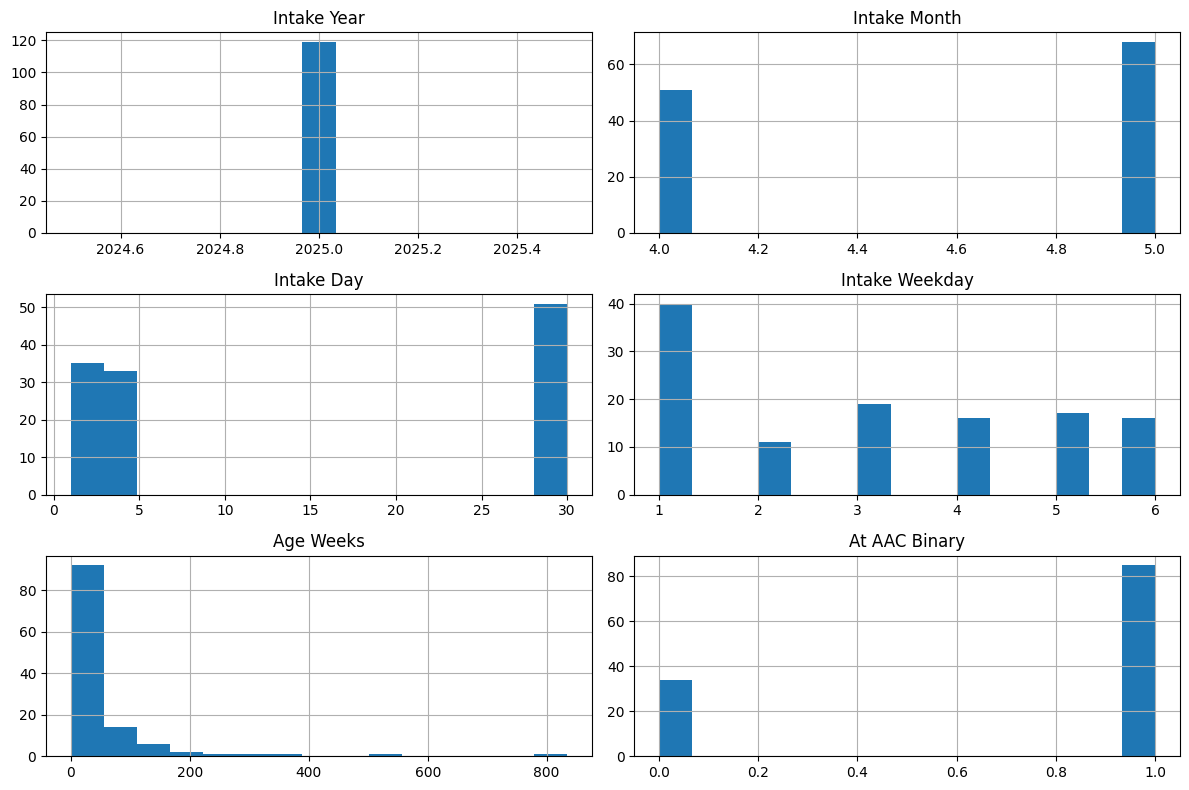

In [ ]:
# Histograms for numeric columns
df[numeric_cols].hist(figsize=(12, 8), bins=15)
plt.tight_layout()
plt.show()

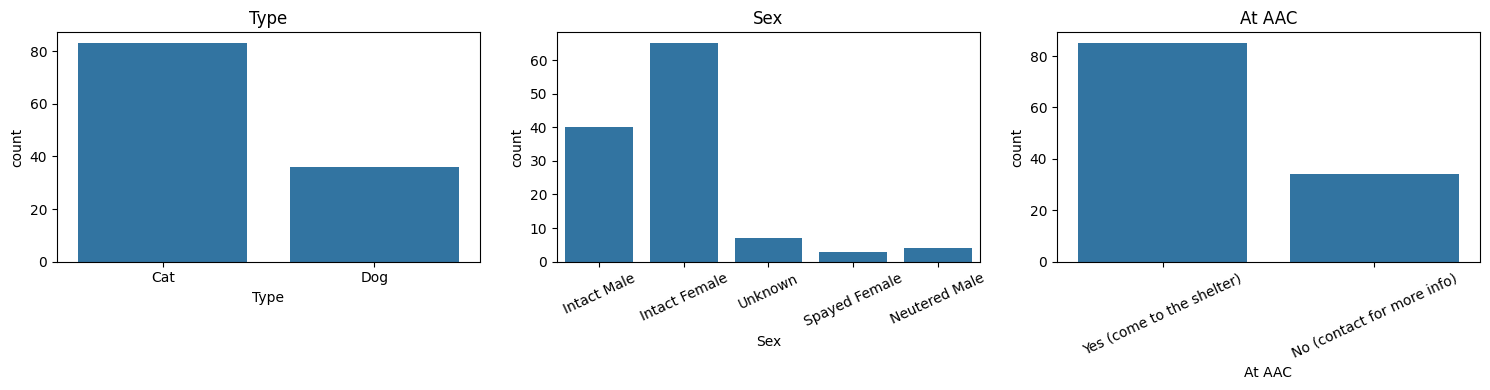

In [ ]:
# Bar charts for main category columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x="Type", ax=axes[0])
axes[0].set_title("Type")

sns.countplot(data=df, x="Sex", ax=axes[1])
axes[1].set_title("Sex")
axes[1].tick_params(axis="x", rotation=25)

sns.countplot(data=df, x="At AAC", ax=axes[2])
axes[2].set_title("At AAC")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

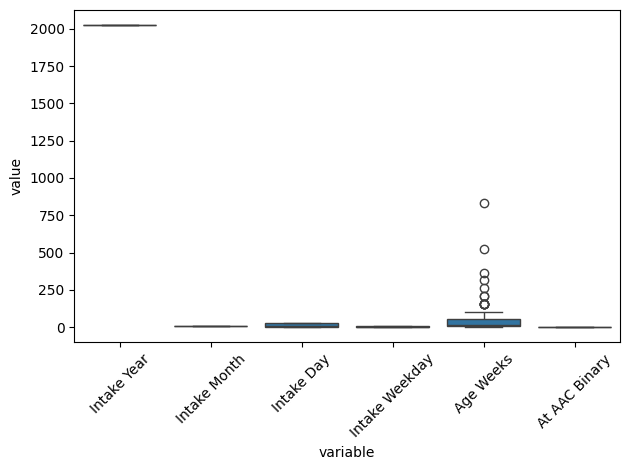

In [ ]:
# One boxplot for all numeric columns
melted = df[numeric_cols].melt(var_name="variable", value_name="value")
sns.boxplot(data=melted, x="variable", y="value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

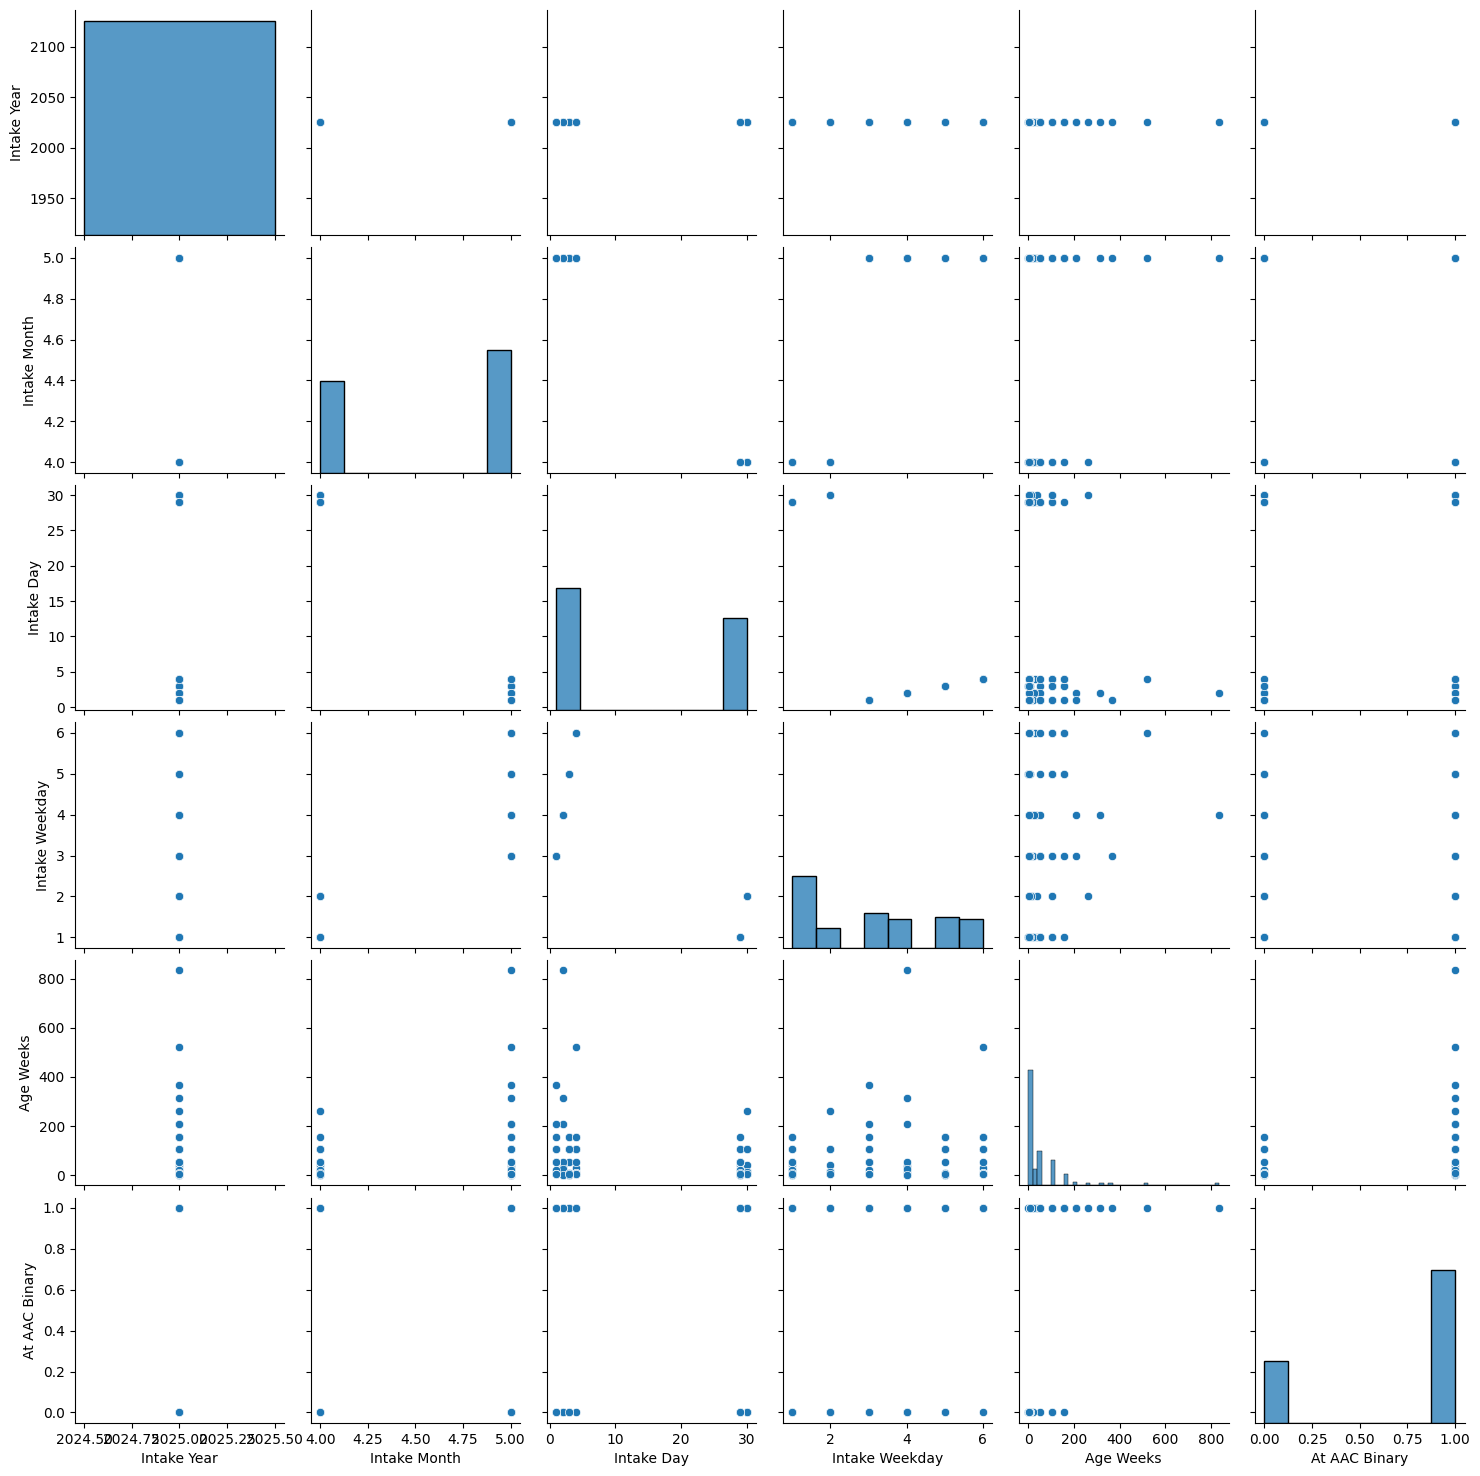

In [ ]:
# Pair plot for numeric columns
sns.pairplot(df[numeric_cols].dropna())
plt.show()

## Categorical vs Categorical

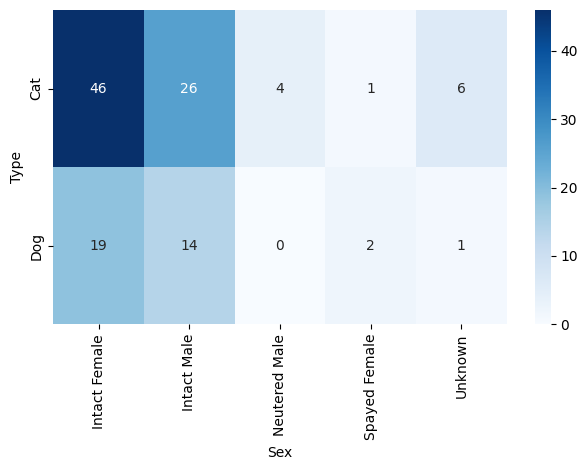

In [ ]:
# Type vs Sex heatmap
ct = pd.crosstab(df["Type"], df["Sex"])
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.tight_layout()
plt.show()

## Categorical vs Numerical

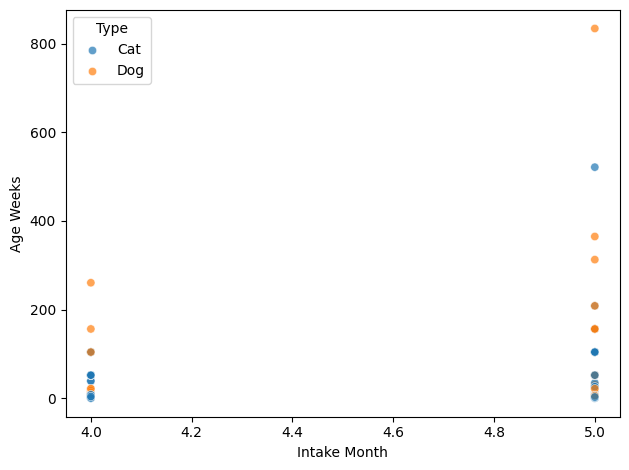

In [ ]:
# Age Weeks vs Intake Month, colored by Type
sns.scatterplot(data=df, x="Intake Month", y="Age Weeks", hue="Type", alpha=0.7)
plt.tight_layout()
plt.show()